In [31]:
import stim
import sys
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

# Clear last example circuits and remake directories:
empty_folder('example_circuits')
empty_folder('example_circuit_diagrams')


## E.g. codes (more in bbparamfuncs.py)
# code = bb6_18_4_4_code()
# code = bb5_48_4_7_code()
# code = bb6_108_code()
# code = gross_code()
# code = two_gross_code()


# Generate circuits:
for code in [bb6_12_4_2(), bb6_12_8_2(), bb6_18_4_4_code()]:
    
    for p in [1e-4, 5e-4, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3]:
        memory_basis = 'X'
        num_rounds = code.d_max

        circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
            code,  
            p,  
            errors = uniform_errors(p),
            idle_during = uniform_idling(p),
            num_syndrome_extraction_cycles = 4,  
            memory_basis = memory_basis,
            exclude_opposite_basis_detectors = True,
            reuse_check_qubits = True,
            sequential_gates = False,
            # only_CZs = True
        )

        # Save circuit:

        filename = f"nkd=[[{code.n}_{code.k}_{code.d_max}]],p={p},b={memory_basis},r={num_rounds},l={code.l},m={code.m},A='{''.join(str(x) + str(y) for x, y in code.Aij)}',B='{''.join(str(x) + str(y) for x, y in code.Bij)}'"

        circuit.to_file(f"example_circuits/{filename}.stim")

        # svg = circuit.without_noise().diagram('timeline-svg')
        # display(svg)
        # svg_string = str(svg)
        # with open(f"example_circuit_diagrams/{filename}.svg", "w", encoding="utf-8") as f: f.write(svg_string)
        # with open(f"example_circuit_diagrams/last_output.svg", "w", encoding="utf-8") as f: f.write(svg_string)


In [32]:
# # Run memory experiment simulations (Takes about )

import sinter
import glob
from stimbposd import SinterDecoder_BPOSD, sinter_decoders

num_processor_cores = 4

circuit_paths = glob.glob(f"example_circuits/*.stim")

csv_path = "example_stats/collected_stats.csv"

tasks = [
    sinter.Task(
        circuit_path = path,
        json_metadata = sinter.comma_separated_key_values(path),
    )
    for path in circuit_paths
]


empty_folder('example_stats') # clear previous example stats

# Collect new stats:
samples = sinter.collect(
    num_workers = num_processor_cores,
    max_shots = 100000,
    max_errors = 100,
    tasks = tasks,
    decoders=['bposd'],
    save_resume_filepath = csv_path,
    custom_decoders = {
        "bposd": SinterDecoder_BPOSD(
            # # max_bp_iters = 30, # DEFAULT_MAX_BP_ITERS = 30
            # bp_method="minimum_sum", # product_sum (default), min_sum, min_sum_log
            # ms_scaling_factor = 0.625, # normalisation
            # schedule="serial",
            # osd_method="osd_cs", # "osd0" - zero-order OSD, "osd_e" - exhaustive OSD, "osd_cs": combination-sweep (default)
            # osd_order=9  # default is 60
            max_bp_iters = 10_000, 
            bp_method = "min_sum", 
            osd_method = "osd_cs", 
            osd_order = 5 
        )
    },
    )

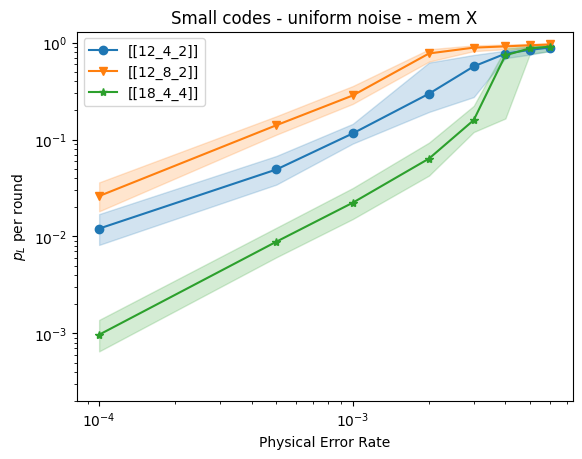

In [34]:
# Plot results:

import matplotlib.pyplot as plt
import sinter
import re

# Plot:
collected_stats = sinter.stats_from_csv_files(f'example_stats/collected_stats.csv')

fig, ax = plt.subplots(1, 1)

sinter.plot_error_rate(
    ax=ax,
    stats=collected_stats,
    group_func=lambda stats: stats.json_metadata['nkd'],
    x_func=lambda stats: stats.json_metadata['p'],
    failure_units_per_shot_func = lambda stats: stats.json_metadata['r'] # set as num_rounds ('r') failure units to find pL per round
     # * int(re.search(r'_(\d{1,2})_', stats.json_metadata['nkd']).group(1)) # set as num_rounds ('r') failure units to find pL per round ... multiply by k to get per logical qubit?
    , 
)

ax.loglog()
ax.legend()
ax.set_ylim(2e-4, 1.3)
ax.set_title("Small codes - uniform noise - mem X")
ax.set_xlabel("Physical Error Rate")
ax.set_ylabel(r"$p_L$ per round");

In [4]:
# Other codes (copy and paste instead of [[30, 4, 5]] above)

# # [[48, 4, 7]] BB5 code from Ye Delfosse long chain [2503.22071] Table II
# l = 8
# m = 3
# # A = x^0 + x
# # B = x^0 + y + x^3 * y^2
# Aij = [(0, 0), (1, 0)]
# Bij = [(0, 0), (0, 1), (3, 2)]
# d = 7

# # [[108, 8, 10]] BB6 code from BB paper [2308.07915] Table III
# l = 9
# m = 6
# # A = x^3 + y + y^2
# # B = y^3 + x + x^2
# Aij = [(3, 0), (0, 1), (0, 2)]
# Bij = [(0, 3), (1, 0), (2, 0)]
# d = 10

# # [[144, 12, 12]] BB6 'gross' code from BB paper [2308.07915] Table III
# l = 12
# m = 6
# # A = x^3 + y + y^2
# # B = y^3 + x + x^2
# Aij = [(3, 0), (0, 1), (0, 2)]
# Bij = [(0, 3), (1, 0), (2, 0)]
# d = 12

# # [[288, 12, 18]] BB6 'two gross' code from BB paper [2308.07915] Table III
# l = 12
# m = 12
# # A = x^3 + y^2 + y^7
# # B = y^3 + x^1 + x^2
# Aij = [(3, 0), (0, 2), (0, 7)]
# Bij = [(0, 3), (1, 0), (2, 0)]
# d = 18